In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.dates as mdates

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [3]:
%pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


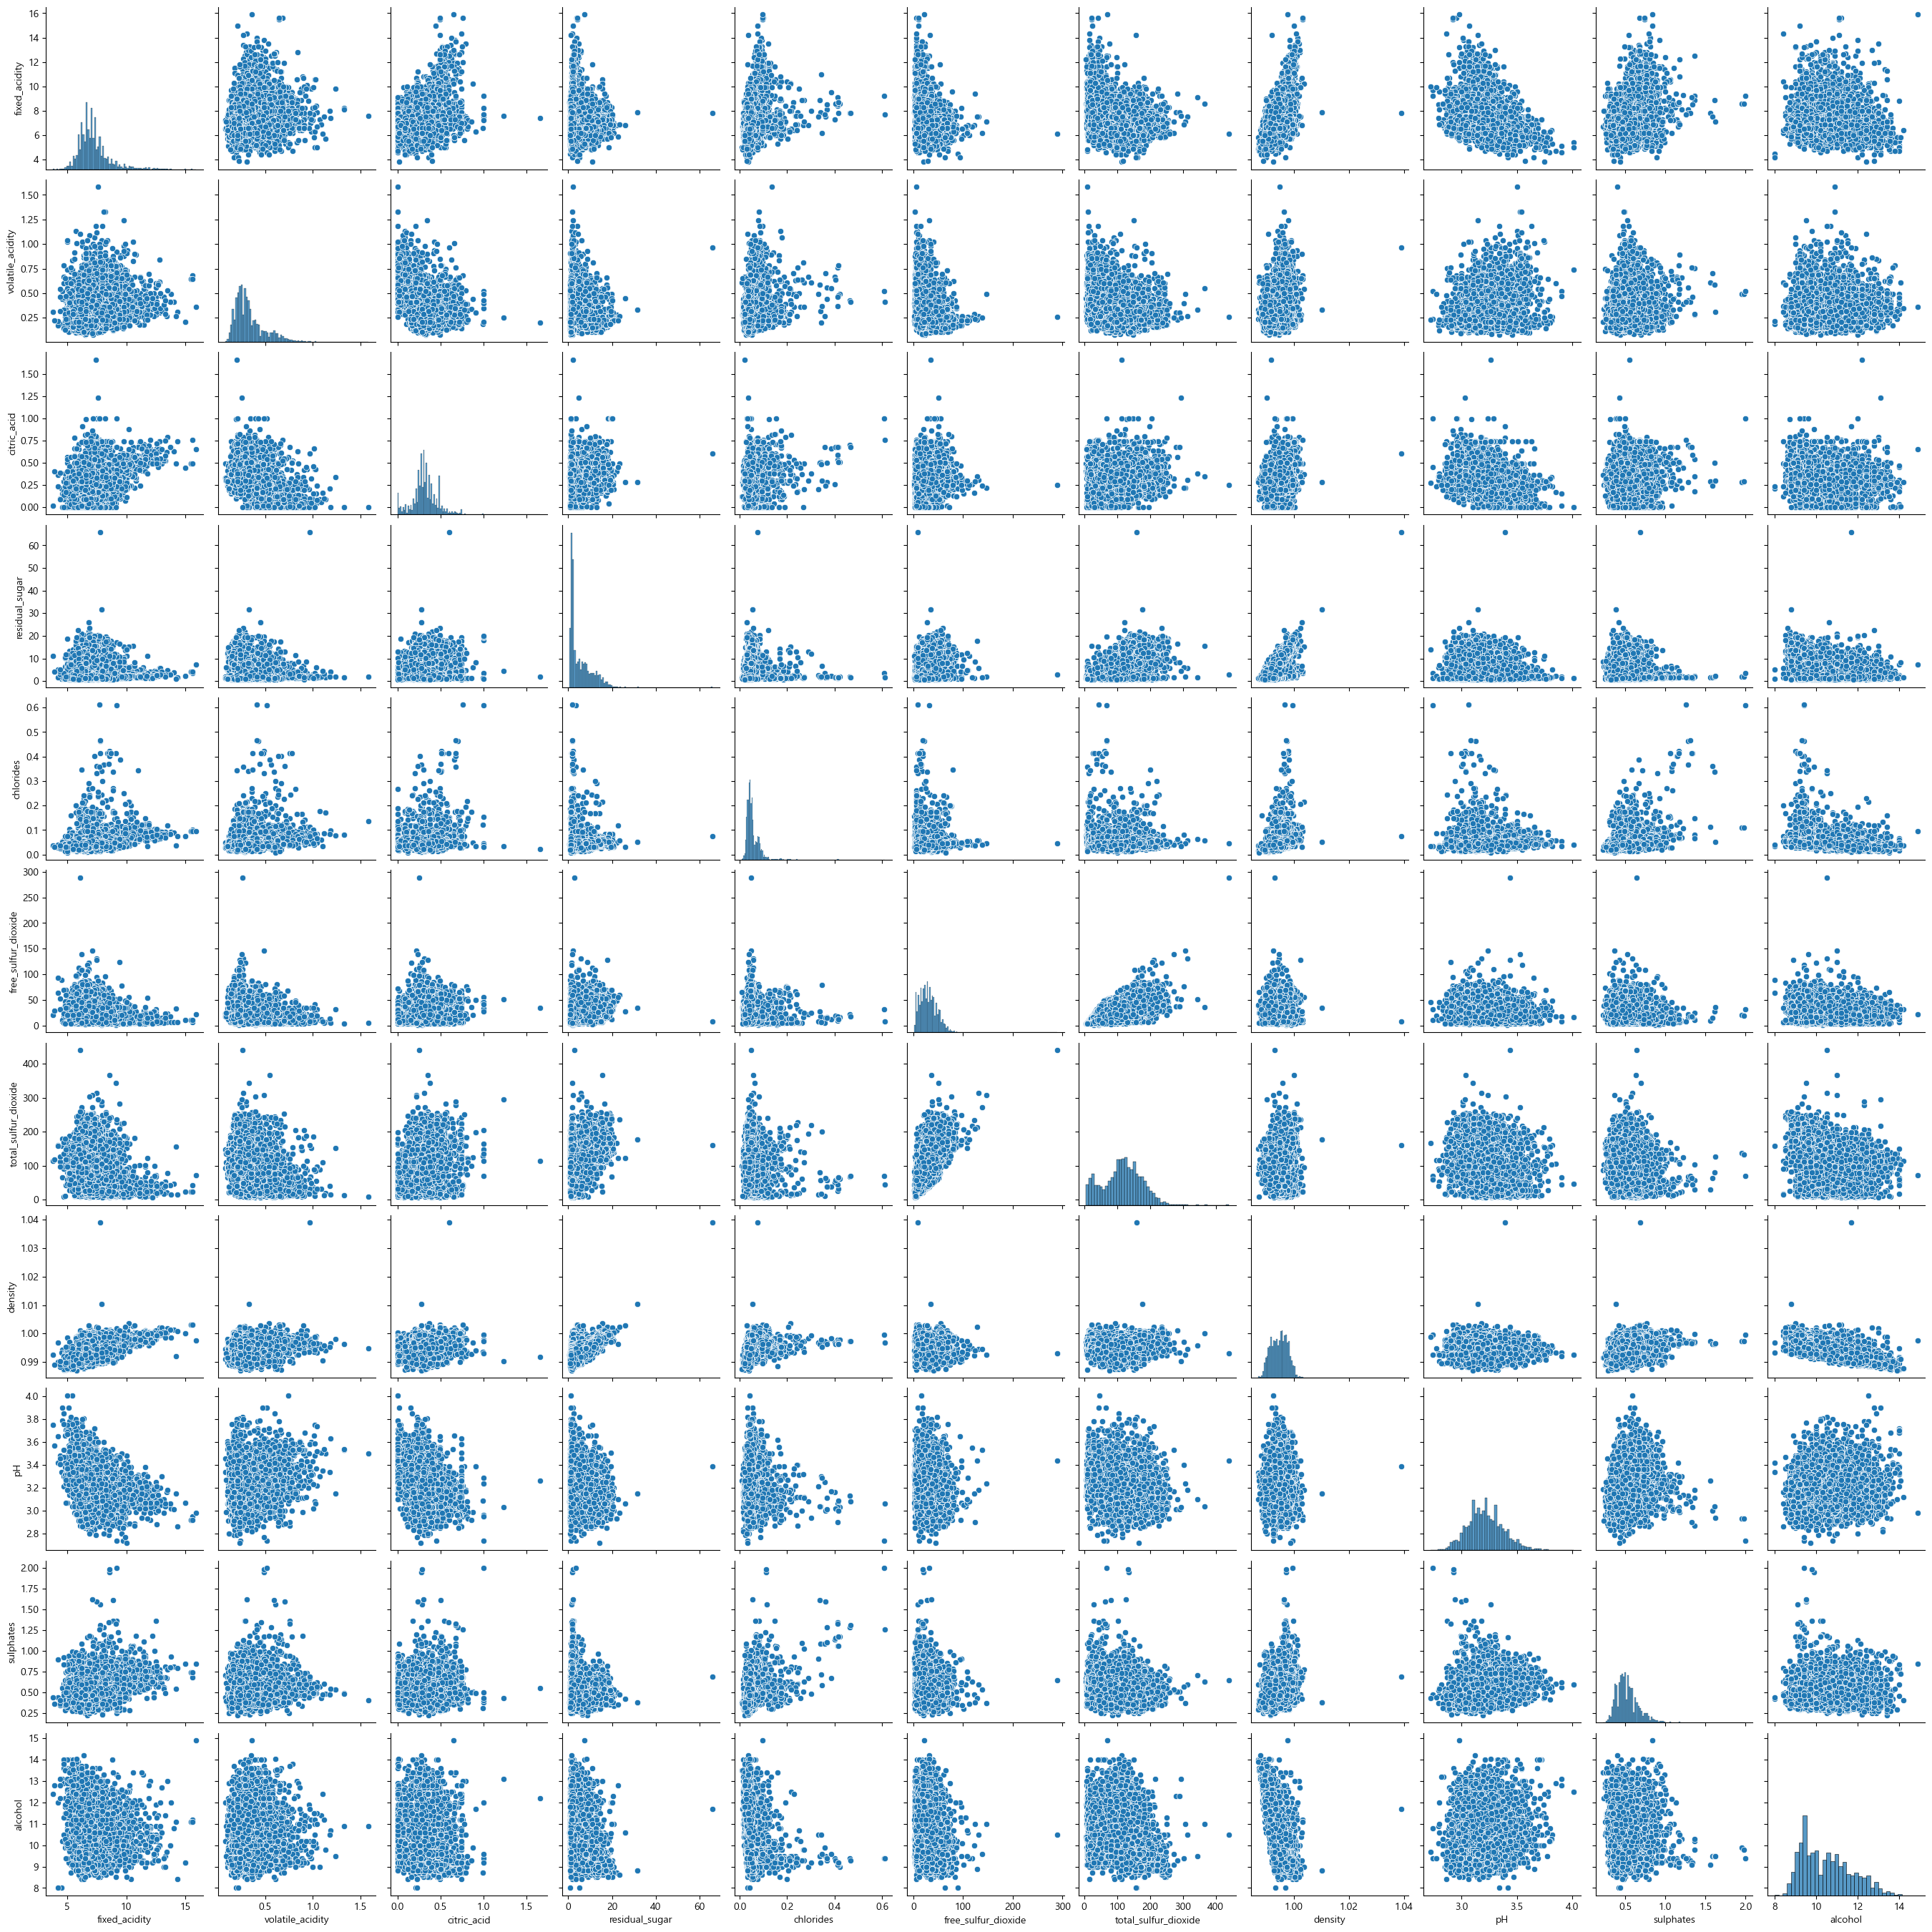

In [58]:
from ucimlrepo import fetch_ucirepo 
import seaborn as sns
import matplotlib.pyplot as plt  
# fetch dataset 
wine_quality = fetch_ucirepo(id=186) 
  
# data (as pandas dataframes) 
X = wine_quality.data.features 
y = wine_quality.data.targets 
# fig,ax = plt.subplots(figsize=(14,6))
sns.pairplot(X)

In [79]:
# 왜도 계산 보완
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
skew_series = X.skew(numeric_only=True).sort_values(ascending=False)
high_skew_feature =  skew_series[skew_series > 1].index
# sns.pairplot(X[high_skew_feature])
X1 = X[high_skew_feature].copy()
x_train,x_test,y_train,y_test = train_test_split(X1,y,test_size=0.2,random_state=42)
model = LinearRegression()
model.fit(x_train,y_train)
model.score(x_test,y_test)

0.11469263111749028

0.11067724627716535

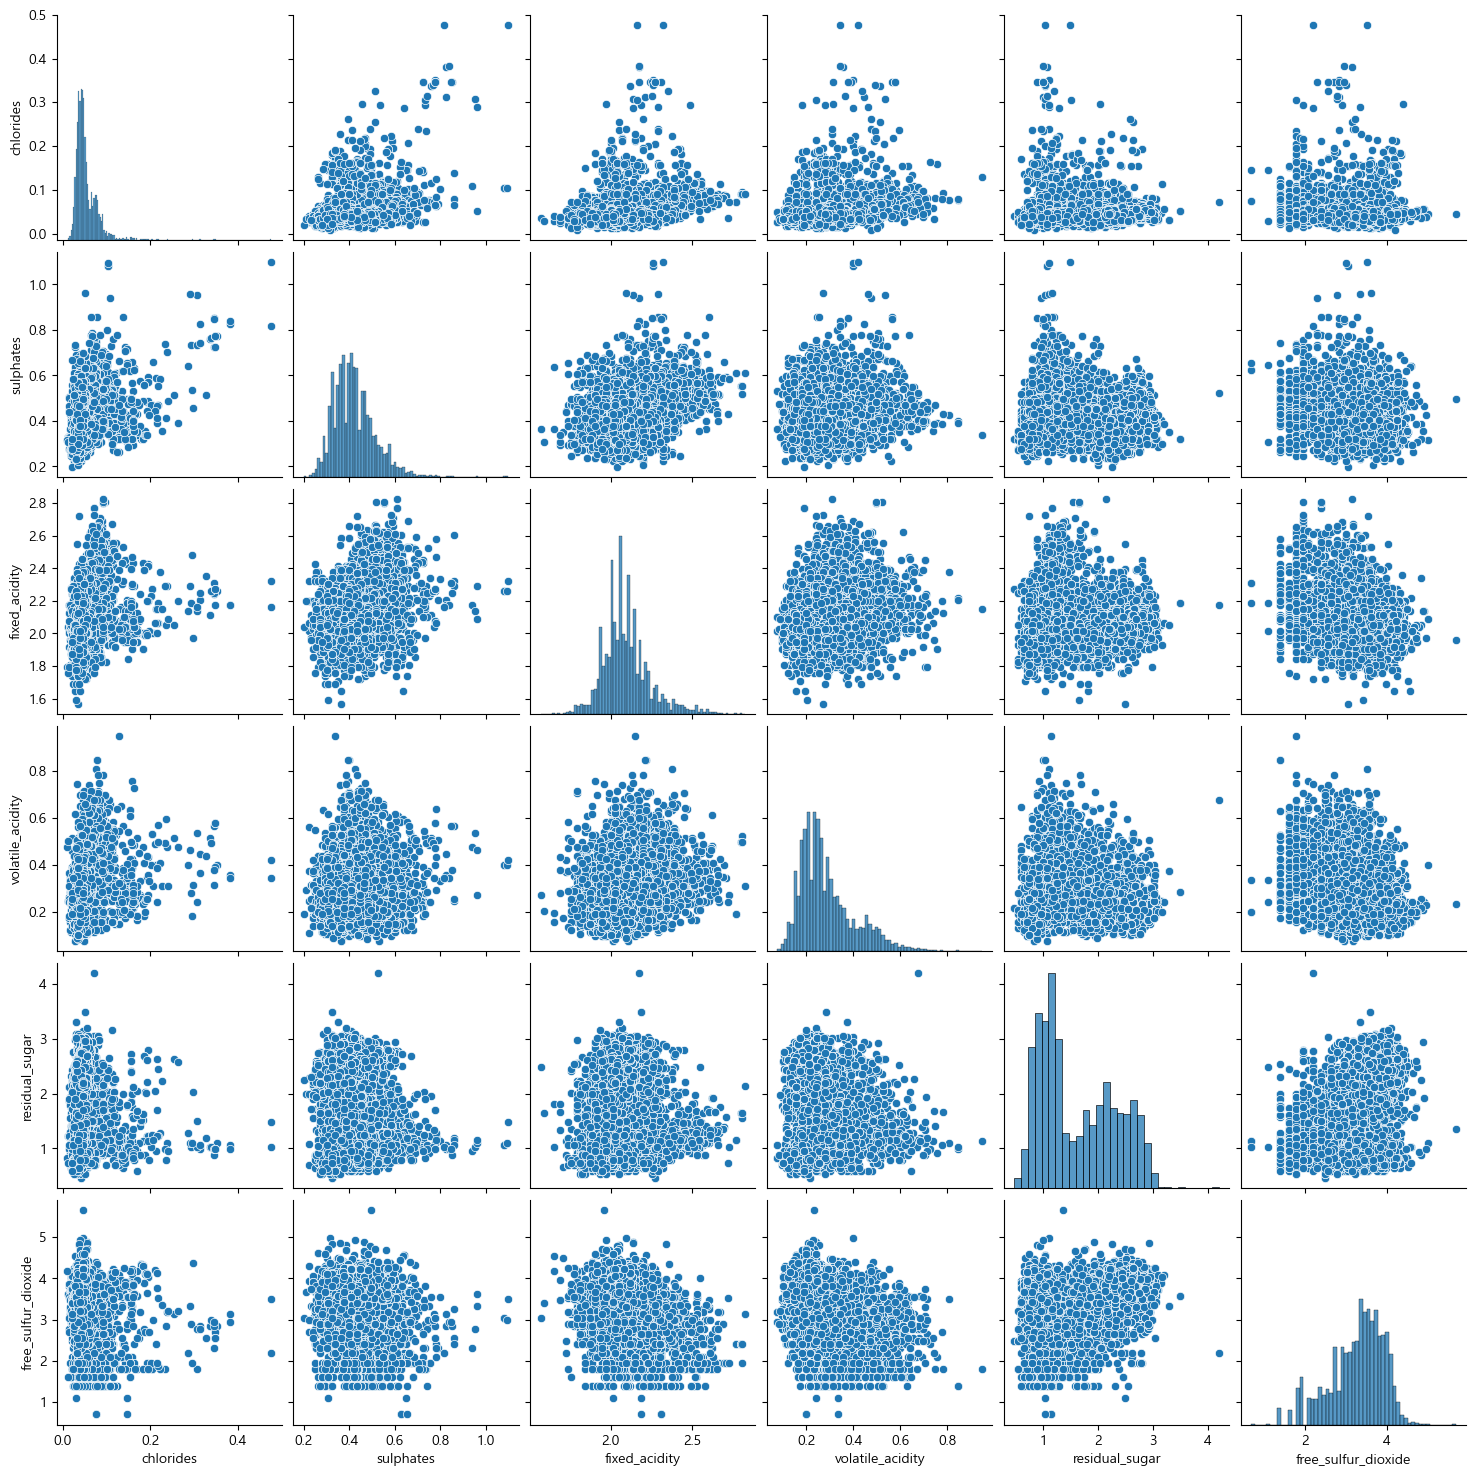

In [80]:
sns.pairplot(np.log1p(X[high_skew_feature]))
X2 = np.log1p(X[high_skew_feature]).copy()
x_train,x_test,y_train,y_test = train_test_split(X2,y,test_size=0.2,random_state=42)
model = LinearRegression()
model.fit(x_train,y_train)
model.score(x_test,y_test)

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=100)

model = LinearRegression()
model.fit(x_train,y_train)

y_predict = model.predict(x_test)

print(f'결정계수 r2_score : {model.score(x_test,y_test)}')

결정계수 r2_score : 0.28471592141470015


In [35]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipeline = Pipeline(steps=[
    ('scaler',StandardScaler() ),('model', LinearRegression())
]
                    )
pipeline.fit(x_train,y_train)
pipeline.score(x_test,y_test)

0.28471592141470137

In [ ]:
pd.concat([X,y],axis=1).corr().loc['quality']

fixed_acidity          -0.076743
volatile_acidity       -0.265699
citric_acid             0.085532
residual_sugar         -0.036980
chlorides              -0.200666
free_sulfur_dioxide     0.055463
total_sulfur_dioxide   -0.041385
density                -0.305858
pH                      0.019506
sulphates               0.038485
alcohol                 0.444319
quality                 1.000000
Name: quality, dtype: float64

0.23838283182207953

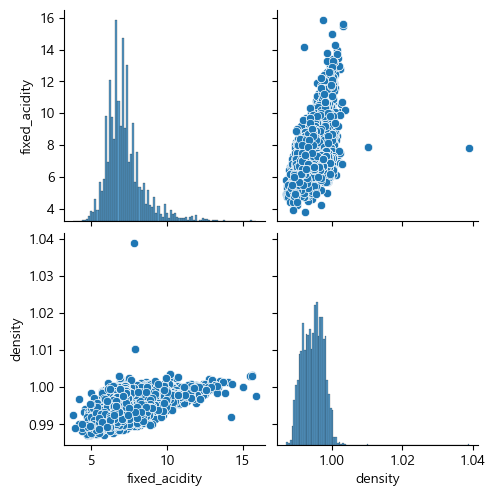

In [54]:
import seaborn as sns
sns.pairplot(X[['fixed_acidity','density']])

x = X[['fixed_acidity']]
y = X['density']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
model = LinearRegression()
model.fit(x_train,y_train)
model.score(x_test,y_test)